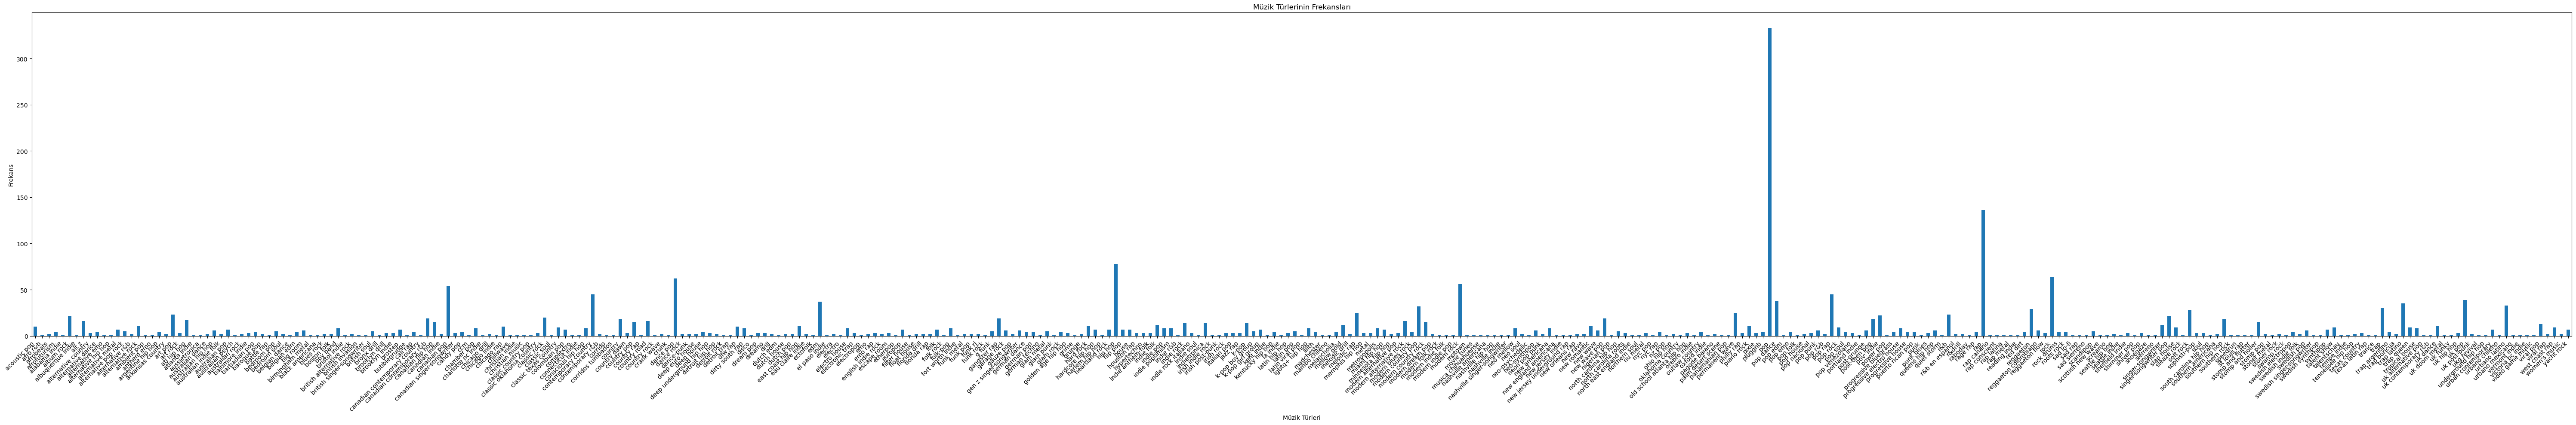

In [1]:
##Artist Genres Frequency

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('newDataset.csv')
genres = df['Artist Genres'].str.get_dummies(sep=', ')
genre_frequencies = genres.sum()


plt.figure(figsize=(60, 10))
genre_frequencies.plot(kind='bar')
plt.xlabel('Müzik Türleri')
plt.ylabel('Frekans')
plt.title('Müzik Türlerinin Frekansları')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout() 
plt.show()


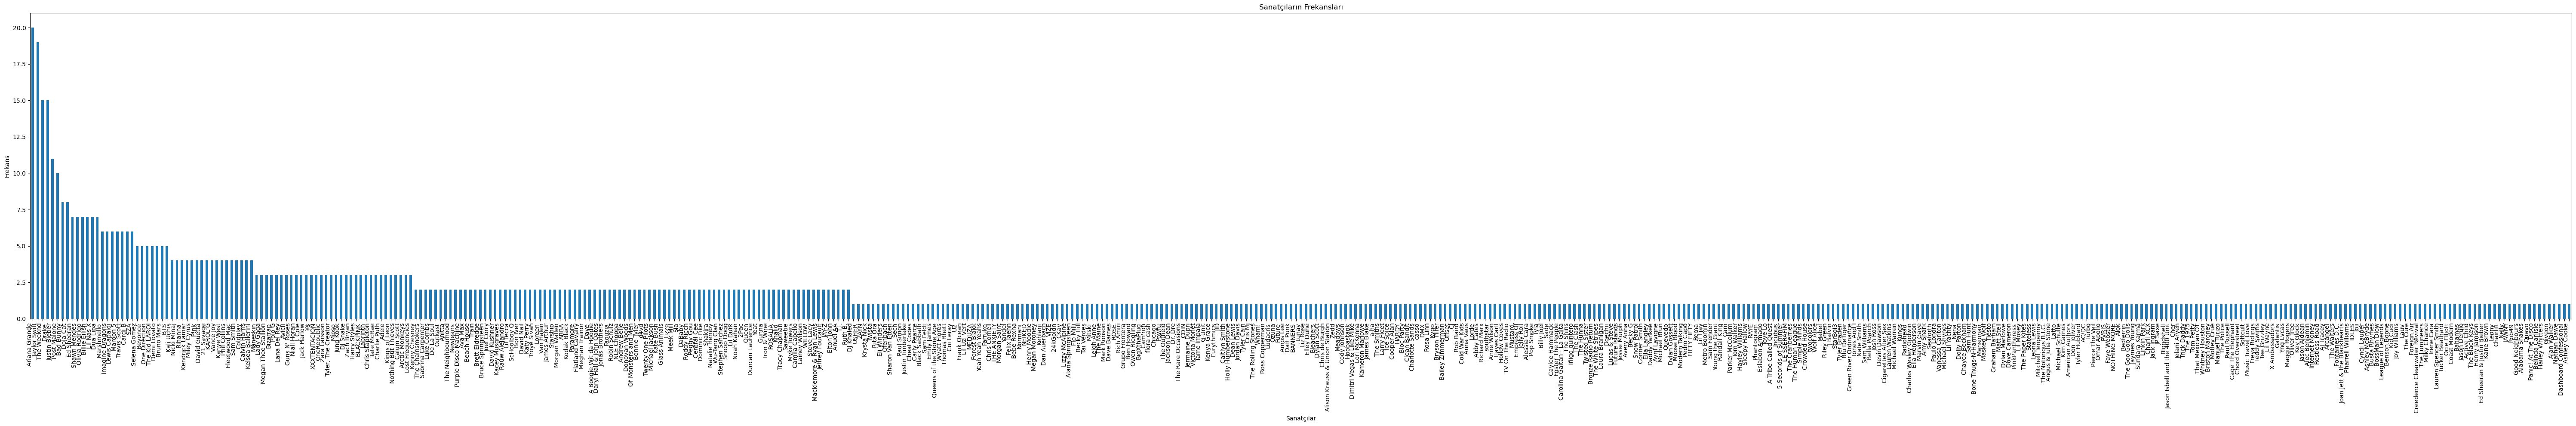

In [2]:
##Artist Frequency

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('newDataset.csv')

artist_frequencies = df['Artist'].value_counts()

#Creating charts
plt.figure(figsize=(60, 10))  
artist_frequencies.plot(kind='bar')
plt.xlabel('Sanatçılar')
plt.ylabel('Frekans')
plt.title('Sanatçıların Frekansları')
plt.xticks(rotation=90, ha='right')  
plt.tight_layout()  
plt.show()


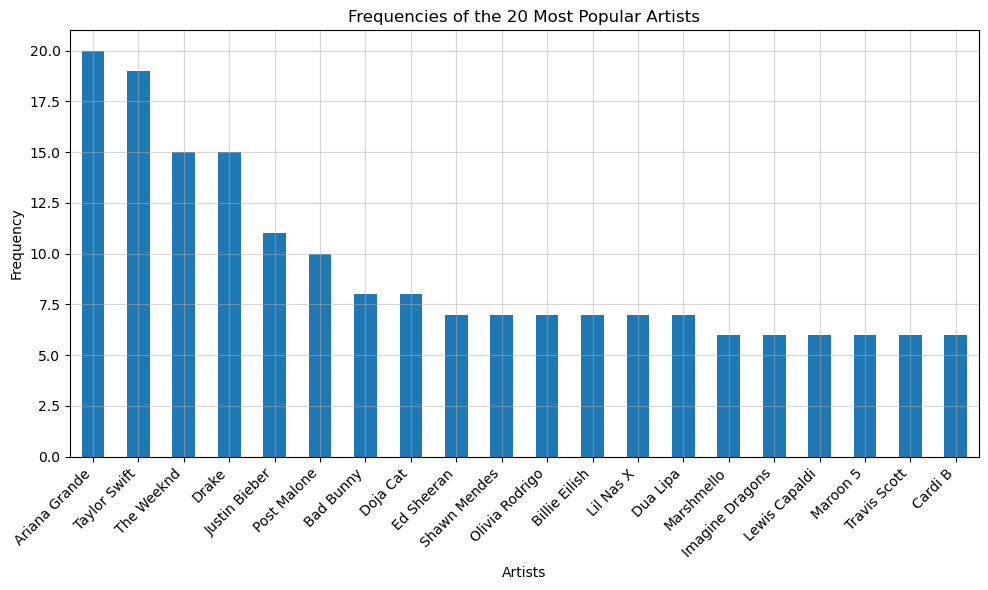

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Veri setini yükle
df = pd.read_csv('newDataset.csv')

# Sanatçıların frekanslarını hesapla
artist_frequencies = df['Artist'].value_counts()

# En popüler 20 sanatçıyı seç
top_artists = artist_frequencies.head(20)

# Grafik oluştur
plt.figure(figsize=(10, 6))
top_artists.plot(kind='bar')

# Eksen etiketlerini ve başlığı ekle
plt.xlabel('Artists')
plt.ylabel('Frequency')
plt.title('Frequencies of the 20 Most Popular Artists')

# Eksen etiketlerinin döndürülmesi ve sağa hizalanması
plt.xticks(rotation=45, ha='right')

# Izgara ekle
plt.grid(alpha=0.5)

# Grafiği göster
plt.tight_layout()
plt.show()


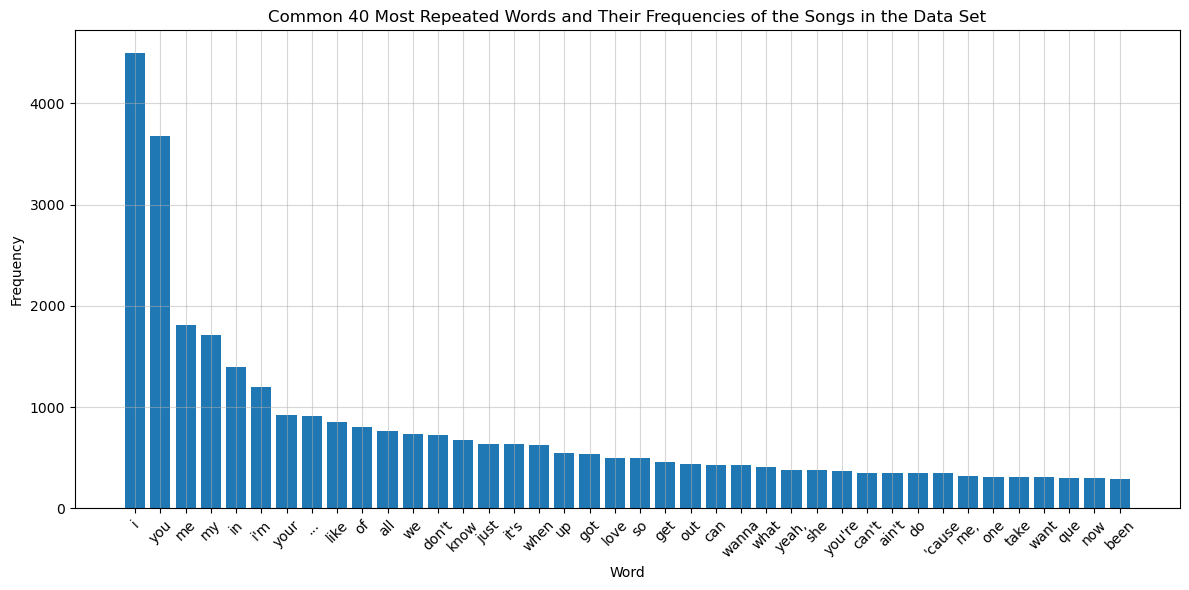

In [4]:
##40 Most Repeated Words and Frequencies

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Reading CSV file
df = pd.read_csv('newDataset.csv')

# Selecting non-empty rows in 'Lyrics' column
lyrics_not_null = df['Lyrics'].dropna()

all_lyrics = ' '.join(lyrics_not_null)

# Stop words list
stop_words = ["a","an","and","are","as","at","be","but","by","for","if",",in","into","is","it","no","on","or","such","that","the","the","their","then","these","they","this","to","was","will","with"] 

word_freq = Counter(all_lyrics.lower().split())

# Remove stop words
for word in stop_words:
    del word_freq[word]

top_words = word_freq.most_common(40)

# Creating charts
plt.figure(figsize=(12, 6))
words, freqs = zip(*top_words)
plt.bar(words, freqs)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Common 40 Most Repeated Words and Their Frequencies of the Songs in the Data Set')
plt.xticks(rotation=45)
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()


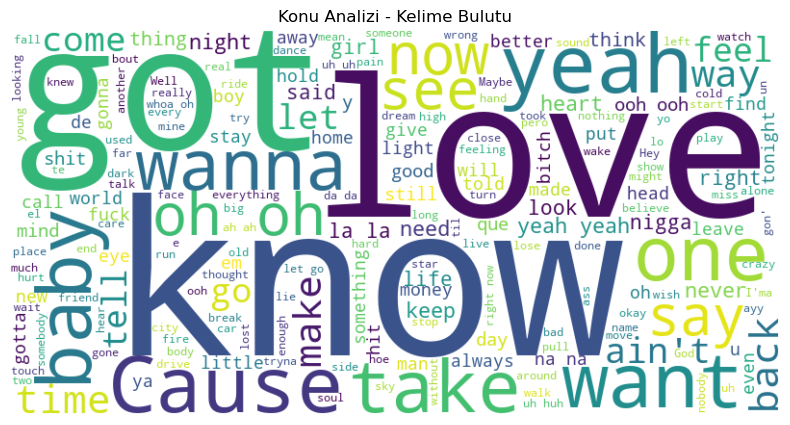

In [5]:
##Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# CSV dosyasını okuma
df = pd.read_csv('newDataset.csv')

# 'Lyrics' sütunundaki boş olmayan satırları seçme ve birleştirme
all_lyrics = ' '.join(df['Lyrics'].dropna())

# Kelime bulutu oluşturma
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lyrics)

# Kelime bulutunu görselleştirme
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Konu Analizi - Kelime Bulutu')
plt.show()

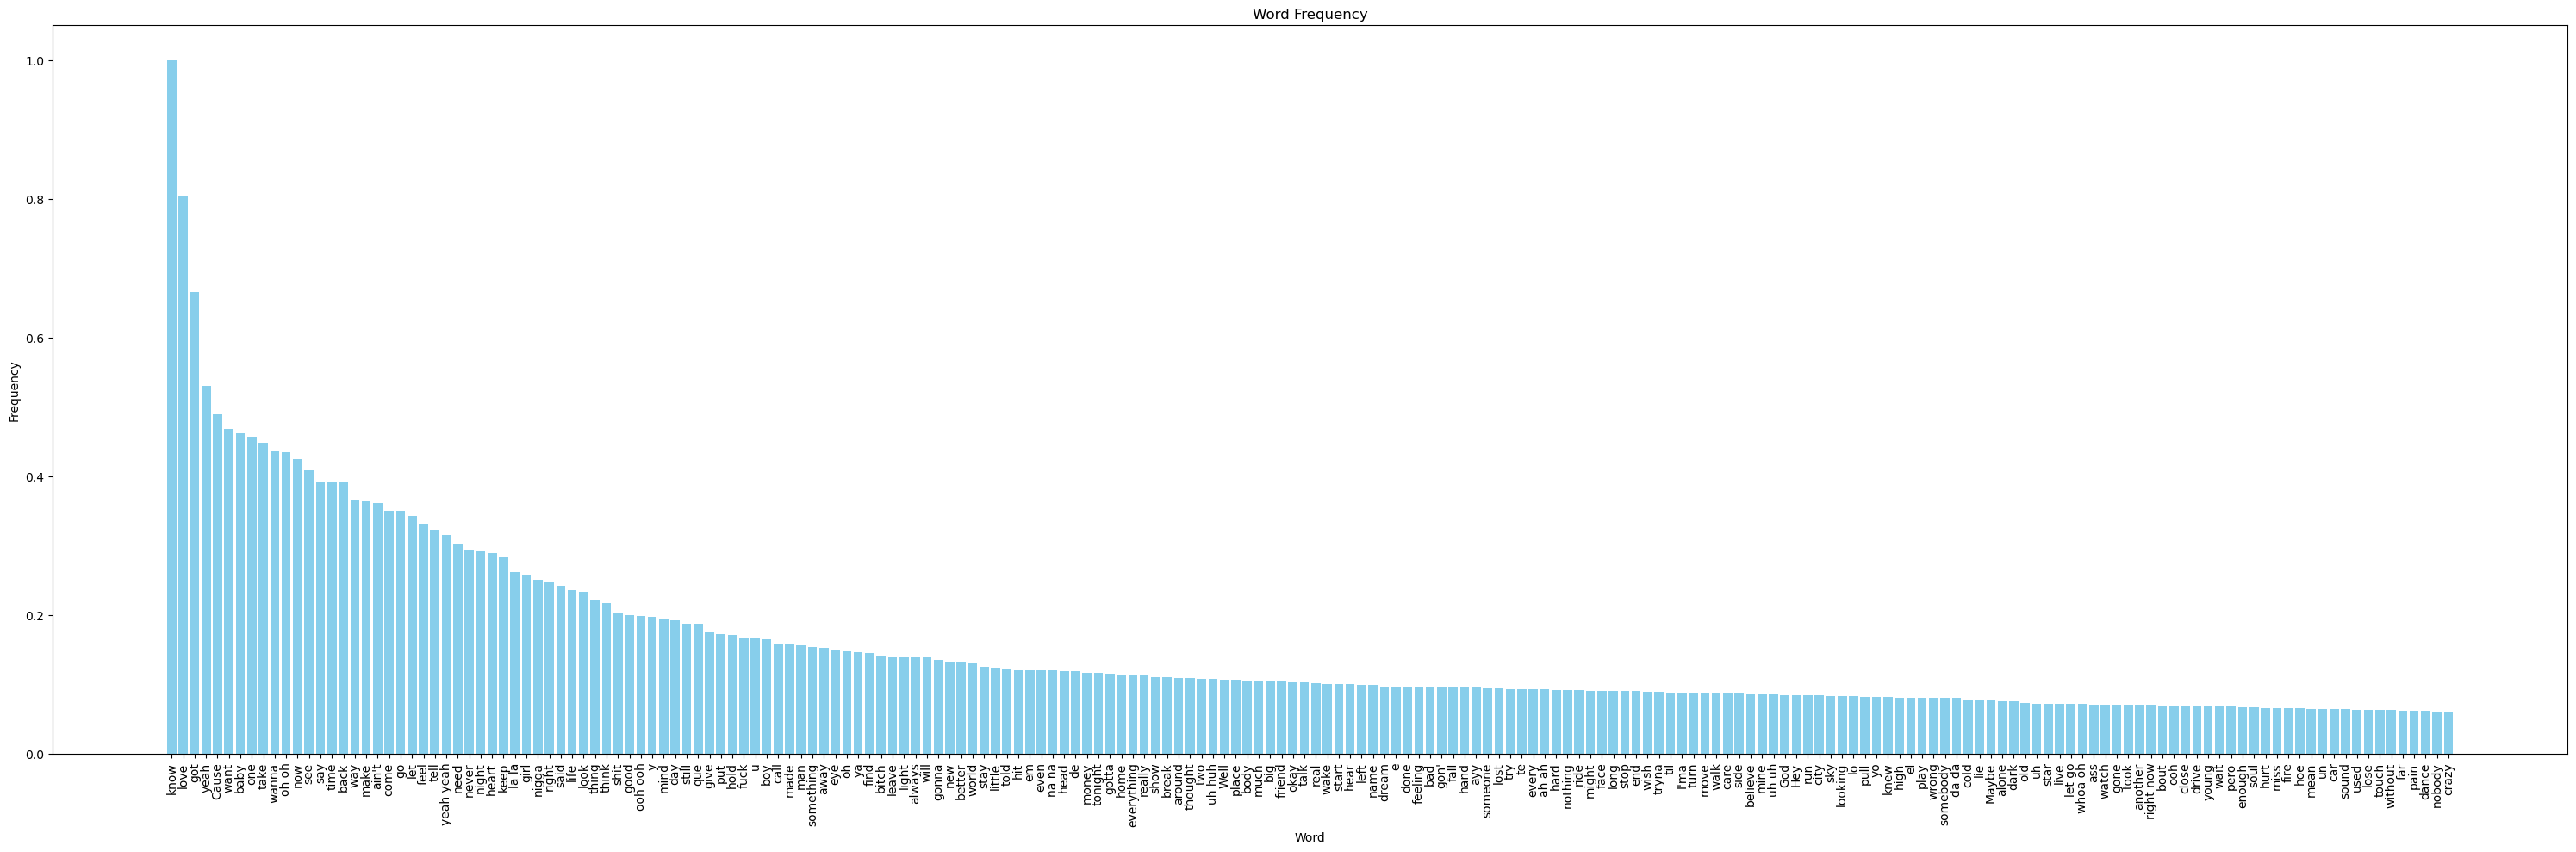

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# CSV dosyasını okuma
df = pd.read_csv('newDataset.csv')

# 'Lyrics' sütunundaki boş olmayan satırları seçme ve birleştirme
all_lyrics = ' '.join(df['Lyrics'].dropna())

# Kelime bulutu oluşturma
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lyrics)

# Kelime ve frekanslarını bir sözlükte saklama
word_freq = wordcloud.words_

# Sözlüğü liste olarak sıralama
sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Kelimeler ve frekansları için ayrı listeler oluşturma
words, freqs = zip(*sorted_word_freq)

# Histogram grafiği oluşturma
plt.figure(figsize=(30, 10))
plt.bar(words, freqs, color='skyblue')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Word Frequency')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


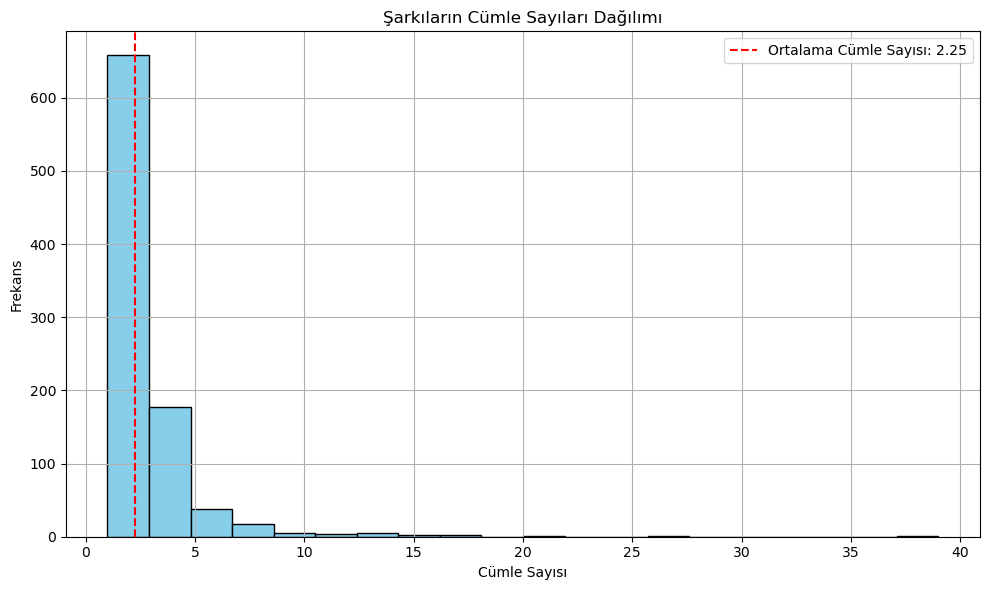

In [7]:
#Cümle Sayısı Analizi
import pandas as pd
import matplotlib.pyplot as plt
import re

# CSV dosyasını okuma
df = pd.read_csv('newDataset.csv')

# 'Lyrics' sütunundaki boş olmayan satırları seçme
lyrics_not_null = df['Lyrics'].dropna()

# Her bir şarkının metin verisindeki cümle sayısını hesaplama
sentence_counts = []
for lyrics in lyrics_not_null:
    # Metindeki cümleleri ayırma
    sentences = re.split(r'[.!?]', lyrics)
    # Boş olmayan cümle sayısını bulma
    non_empty_sentence_count = sum(1 for sentence in sentences if sentence.strip())
    sentence_counts.append(non_empty_sentence_count)

# Tüm şarkıların ortalama cümle sayısını hesaplama
average_sentence_count = sum(sentence_counts) / len(sentence_counts)

# Grafik oluşturma
plt.figure(figsize=(10, 6))
plt.hist(sentence_counts, bins=20, color='skyblue', edgecolor='black')
plt.axvline(x=average_sentence_count, color='red', linestyle='--', label=f'Ortalama Cümle Sayısı: {average_sentence_count:.2f}')
plt.xlabel('Cümle Sayısı')
plt.ylabel('Frekans')
plt.title('Şarkıların Cümle Sayıları Dağılımı')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
